# MND Python

## MNDのインストール

In [47]:
import mne

# MNE Pythonのバージョンを表示
print(mne.__version__)

# MNE Pythonの関数一覧を表示
print(dir(mne))

1.12.0
['AcqParserFIF', 'Annotations', 'BaseEpochs', 'BiHemiLabel', 'Covariance', 'Dipole', 'DipoleFixed', 'Epochs', 'EpochsArray', 'Evoked', 'EvokedArray', 'Forward', 'HEDAnnotations', 'Info', 'Label', 'MixedSourceEstimate', 'MixedVectorSourceEstimate', 'Projection', 'Report', 'SourceEstimate', 'SourceMorph', 'SourceSpaces', 'Transform', 'VectorSourceEstimate', 'VolSourceEstimate', 'VolVectorSourceEstimate', 'add_reference_channels', 'add_source_space_distances', 'annotations_from_events', 'apply_forward', 'apply_forward_raw', 'average_forward_solutions', 'beamformer', 'bem', 'channel_indices_by_type', 'channel_type', 'channels', 'chpi', 'combine_evoked', 'commands', 'compute_covariance', 'compute_proj_epochs', 'compute_proj_evoked', 'compute_proj_raw', 'compute_rank', 'compute_raw_covariance', 'compute_source_morph', 'concatenate_epochs', 'concatenate_events', 'concatenate_raws', 'convert_forward_solution', 'coreg', 'count_annotations', 'count_events', 'create_default_subject', 'crea

In [48]:
pip install mne

Note: you may need to restart the kernel to use updated packages.


In [49]:
import mne

# MNE Pythonのバージョンを表示
print(mne.__version__)

# MNE Pythonの関数一覧を表示
print(dir(mne))

1.12.0
['AcqParserFIF', 'Annotations', 'BaseEpochs', 'BiHemiLabel', 'Covariance', 'Dipole', 'DipoleFixed', 'Epochs', 'EpochsArray', 'Evoked', 'EvokedArray', 'Forward', 'HEDAnnotations', 'Info', 'Label', 'MixedSourceEstimate', 'MixedVectorSourceEstimate', 'Projection', 'Report', 'SourceEstimate', 'SourceMorph', 'SourceSpaces', 'Transform', 'VectorSourceEstimate', 'VolSourceEstimate', 'VolVectorSourceEstimate', 'add_reference_channels', 'add_source_space_distances', 'annotations_from_events', 'apply_forward', 'apply_forward_raw', 'average_forward_solutions', 'beamformer', 'bem', 'channel_indices_by_type', 'channel_type', 'channels', 'chpi', 'combine_evoked', 'commands', 'compute_covariance', 'compute_proj_epochs', 'compute_proj_evoked', 'compute_proj_raw', 'compute_rank', 'compute_raw_covariance', 'compute_source_morph', 'concatenate_epochs', 'concatenate_events', 'concatenate_raws', 'convert_forward_solution', 'coreg', 'count_annotations', 'count_events', 'create_default_subject', 'crea

## MNE Pythonの基本的な使い方

### 脳波データの読み込み方法

In [50]:
import os
import numpy as np
import mne

In [51]:
import mne

# .edfファイルの読み込み
raw = mne.io.read_raw_edf("testdate.edf", preload=True)

Extracting EDF parameters from testdate.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 7949999  =      0.000 ... 79499.990 secs...


/var/folders/r2/yjkrndnx33n8krpswxxg9vqr0000gn/T/ipykernel_45933/334764030.py:4: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf("testdate.edf", preload=True)
/var/folders/r2/yjkrndnx33n8krpswxxg9vqr0000gn/T/ipykernel_45933/334764030.py:4: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw = mne.io.read_raw_edf("testdate.edf", preload=True)
/var/folders/r2/yjkrndnx33n8krpswxxg9vqr0000gn/T/ipykernel_45933/334764030.py:4: RuntimeWarning: Highpass cutoff frequency 16.0 is greater than lowpass cutoff frequency 0.7, setting values to 0 and Nyquist.
  raw = mne.io.read_raw_edf("testdate.edf", preload=True)


### 脳波データの前処理（フィルタリング、アーチファクト除去など）

In [ ]:
picks = mne.pick_types(raw.info, eeg=True)

# ハイパスフィルタ（1Hz以下をカット）
raw.filter(1, None, fir_design='firwin')

# ローパスフィルタ（40Hz以上をカット）
raw.filter(None, 40, fir_design='firwin')

# ノッチフィルタ（49Hzを除去）
raw.notch_filter(freqs=[49], picks=picks, method='fir')

Filtering raw data in 1 contiguous segment
Setting up high-pass filter at 1 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal highpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Filter length: 331 samples (3.310 s)

Filtering raw data in 1 contiguous segment
Setting up low-pass filter at 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 33 samples (0.330 s)

Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 48 - 50 Hz

FIR filter p

<RawEDF | testdate.edf, 7 x 7950000 (79500.0 s), ~424.6 MiB, data loaded>

In [53]:
# 250Hzにリサンプリング
raw.resample(250, npad="auto")

<RawEDF | testdate.edf, 7 x 19875000 (79500.0 s), ~1.04 GiB, data loaded>

### 脳波データの可視化（波形表示、トポグラフィー表示など）

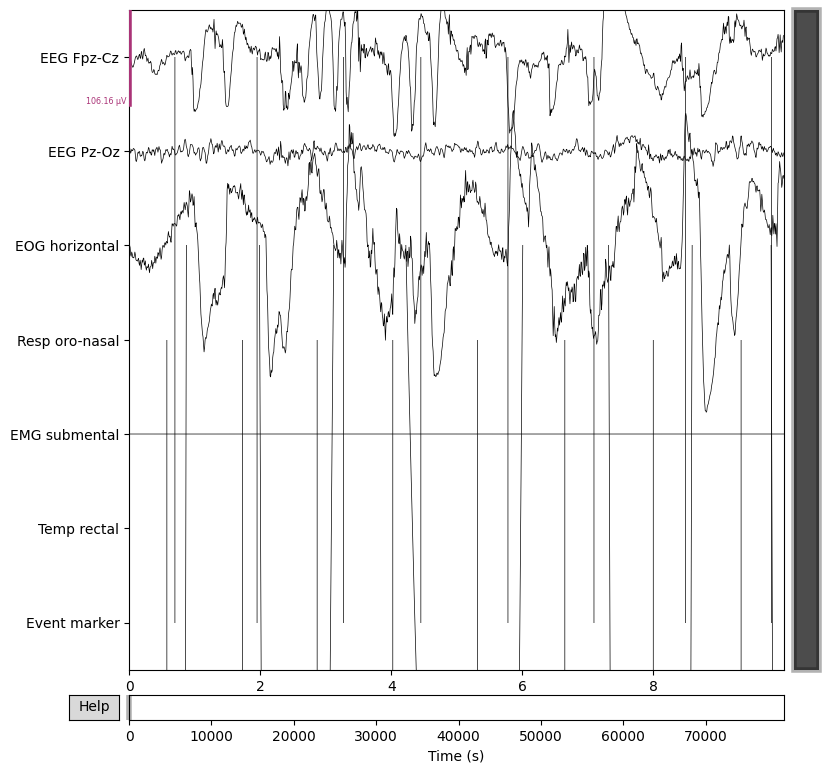

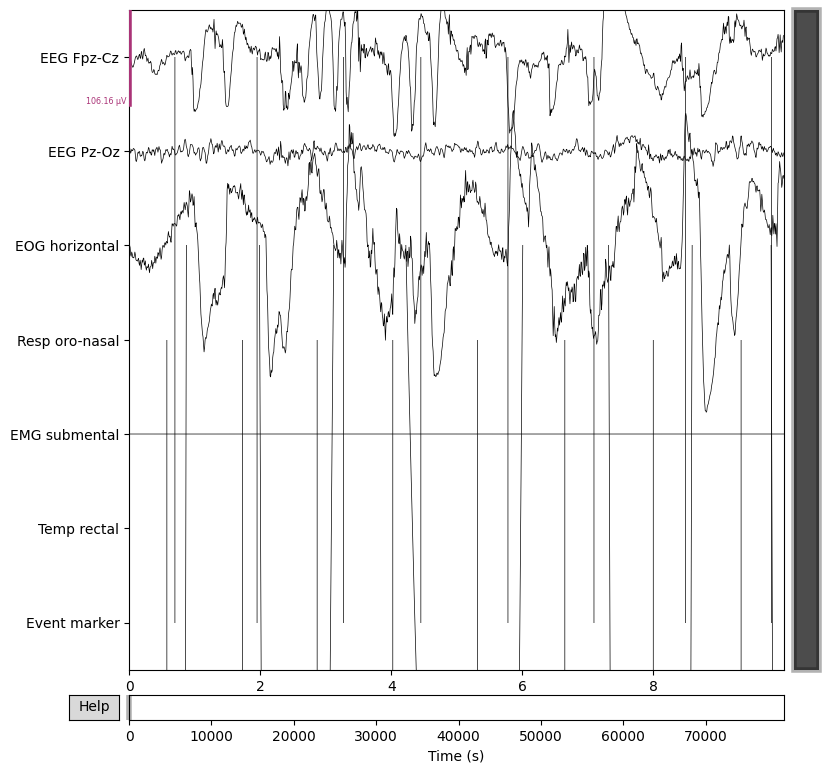

In [54]:
# 波形の表示
raw.plot(n_channels=10, scalings='auto', title='Raw EEG Data', show=True, block=True)

In [55]:
print(raw.ch_names)

['EEG Fpz-Cz', 'EEG Pz-Oz', 'EOG horizontal', 'Resp oro-nasal', 'EMG submental', 'Temp rectal', 'Event marker']


In [56]:
# データの定義
data = raw.get_data()

# トポグラフィーの表示
mne.viz.plot_topomap(data[:, 0], raw.info, show=False)

RuntimeError: No digitization points found.

Not setting metadata
39750 matching events found
Setting baseline interval to [-1.0, 0.0] s
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 39750 events and 751 original time points ...
2 bad epochs dropped
NOTE: tfr_morlet() is a legacy function. New code should use .compute_tfr(method="morlet").
No baseline correction applied


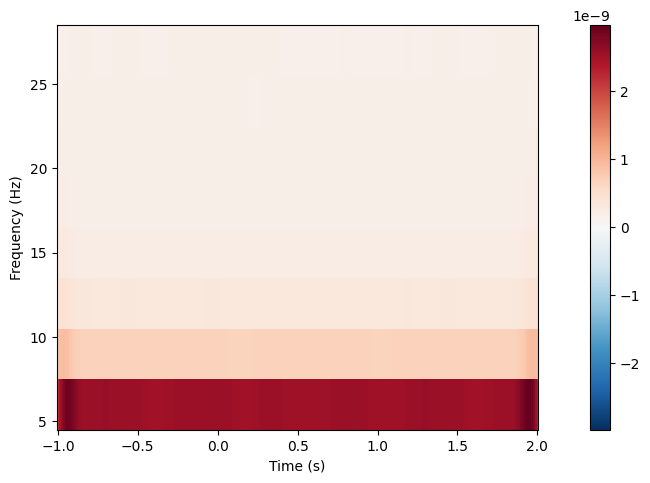

[<Figure size 640x480 with 2 Axes>]

In [ ]:
# エポック作成
events = mne.make_fixed_length_events(raw, duration=2.0)
epochs = mne.Epochs(raw, events, tmin=-1.0, tmax=2.0, preload=True)

# 時間周波数解析
freqs = np.arange(6, 30, 3)  # 分析する周波数帯域
n_cycles = freqs / 2.  # 各周波数におけるモルレーウェーブレットのサイクル数
power = mne.time_frequency.tfr_morlet(epochs, freqs=freqs, n_cycles=n_cycles, use_fft=True, return_itc=False, decim=3, n_jobs=1)

# 時間周波数解析結果の可視化
# power.plot([0], baseline=(-1.0, 0), mode='logratio', vlim=(-1, 1), title='Time-Frequency Power')
power.plot([0], baseline=None)